In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
df = pd.read_csv("Dataset .csv")

print("✅ Dataset Loaded Successfully!")
print("="*60)
print("📊 DATASET OVERVIEW")
print("="*60)

print(f"\nNumber of Rows    : {df.shape[0]}")
print(f"Number of Columns : {df.shape[1]}")

print("\n📌 Column Names:")
for col in df.columns:
    print("-", col)

print("\n📌 First 5 Records:")
display(df.head())

✅ Dataset Loaded Successfully!
📊 DATASET OVERVIEW

Number of Rows    : 9551
Number of Columns : 21

📌 Column Names:
- Restaurant ID
- Restaurant Name
- Country Code
- City
- Address
- Locality
- Locality Verbose
- Longitude
- Latitude
- Cuisines
- Average Cost for two
- Currency
- Has Table booking
- Has Online delivery
- Is delivering now
- Switch to order menu
- Price range
- Aggregate rating
- Rating color
- Rating text
- Votes

📌 First 5 Records:


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,Average Cost for two,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",1100,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,1200,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",4000,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",1500,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",1500,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


In [4]:
print("="*60)
print("📋 DATASET INFORMATION")
print("="*60)
df.info()

📋 DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Restaurant ID         9551 non-null   int64  
 1   Restaurant Name       9551 non-null   object 
 2   Country Code          9551 non-null   int64  
 3   City                  9551 non-null   object 
 4   Address               9551 non-null   object 
 5   Locality              9551 non-null   object 
 6   Locality Verbose      9551 non-null   object 
 7   Longitude             9551 non-null   float64
 8   Latitude              9551 non-null   float64
 9   Cuisines              9542 non-null   object 
 10  Average Cost for two  9551 non-null   int64  
 11  Currency              9551 non-null   object 
 12  Has Table booking     9551 non-null   object 
 13  Has Online delivery   9551 non-null   object 
 14  Is delivering now     9551 non-null   object 
 15 

In [5]:
print("="*60)
print("🔍 MISSING VALUE ANALYSIS")
print("="*60)

missing_values = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage (%)": round((missing_values / len(df)) * 100, 2)
})

display(missing_df[missing_df["Missing Values"] > 0])

🔍 MISSING VALUE ANALYSIS


,Missing Values,Percentage (%)
Cuisines,9,0.09


In [9]:
# ==========================
# HANDLE MISSING VALUES
# ==========================

print("="*60)
print("MISSING VALUE TREATMENT")
print("="*60)

# Separate numerical and categorical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

# Fill numerical columns with median
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

# Fill categorical columns with mode
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

# Verify missing values
print("\nRemaining Missing Values in Each Column:")
print(df.isnull().sum())

print("\nTotal Missing Values Remaining:")
print(df.isnull().sum().sum())

MISSING VALUE TREATMENT

Remaining Missing Values in Each Column:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64

Total Missing Values Remaining:
0


In [10]:
print("="*60)
print("🛠 DATA TYPE CHECK")
print("="*60)

display(pd.DataFrame(df.dtypes, columns=["Data Type"]))

🛠 DATA TYPE CHECK


,Data Type
Restaurant ID,int64
Restaurant Name,object
Country Code,int64
City,object
Address,object
Locality,object
Locality Verbose,object
Longitude,float64
Latitude,float64
Cuisines,object


In [11]:
df["Aggregate rating"] = pd.to_numeric(
    df["Aggregate rating"],
    errors="coerce"
)
print("✅ Aggregate Rating Converted to Numeric Format")

✅ Aggregate Rating Converted to Numeric Format


In [12]:
print("="*60)
print("⭐ AGGREGATE RATING SUMMARY")
print("="*60)
display(df["Aggregate rating"].describe())

⭐ AGGREGATE RATING SUMMARY


count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

In [13]:
rating_counts = df["Aggregate rating"].value_counts().sort_index()

rating_table = pd.DataFrame({
    "Aggregate Rating": rating_counts.index,
    "Frequency": rating_counts.values
})

display(rating_table)

,Aggregate Rating,Frequency
0,0.0,2148
1,1.8,1
2,1.9,2
3,2.0,7
4,2.1,15
5,2.2,27
6,2.3,47
7,2.4,87
8,2.5,110
9,2.6,191


In [14]:
rating_percentage = round(
    df["Aggregate rating"]
    .value_counts(normalize=True)
    .sort_index() * 100,
    2
)
percentage_table = pd.DataFrame({
    "Aggregate Rating": rating_percentage.index,
    "Percentage (%)": rating_percentage.values
})
display(percentage_table)

,Aggregate Rating,Percentage (%)
0,0.0,22.49
1,1.8,0.01
2,1.9,0.02
3,2.0,0.07
4,2.1,0.16
5,2.2,0.28
6,2.3,0.49
7,2.4,0.91
8,2.5,1.15
9,2.6,2.00


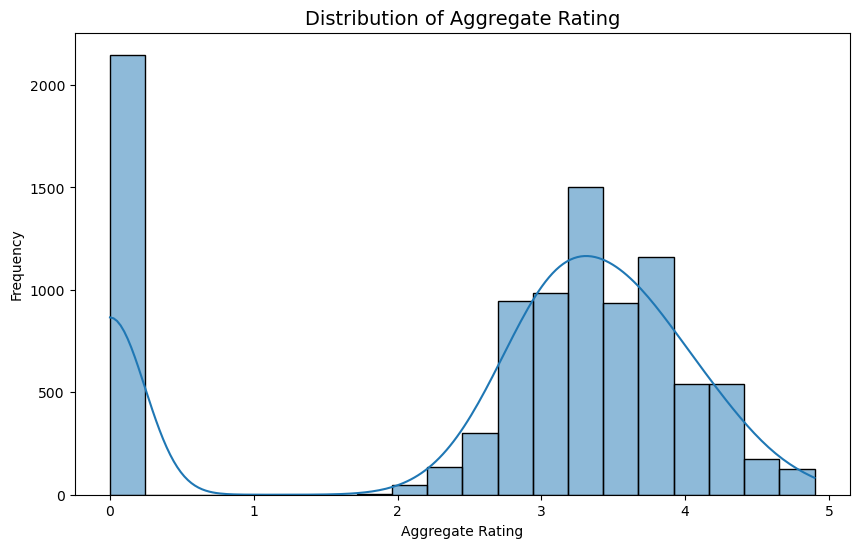

In [15]:
plt.figure(figsize=(10,6))
sns.histplot(
    df["Aggregate rating"],
    bins=20,
    kde=True
)
plt.title("Distribution of Aggregate Rating", fontsize=14)
plt.xlabel("Aggregate Rating")
plt.ylabel("Frequency")
plt.show()

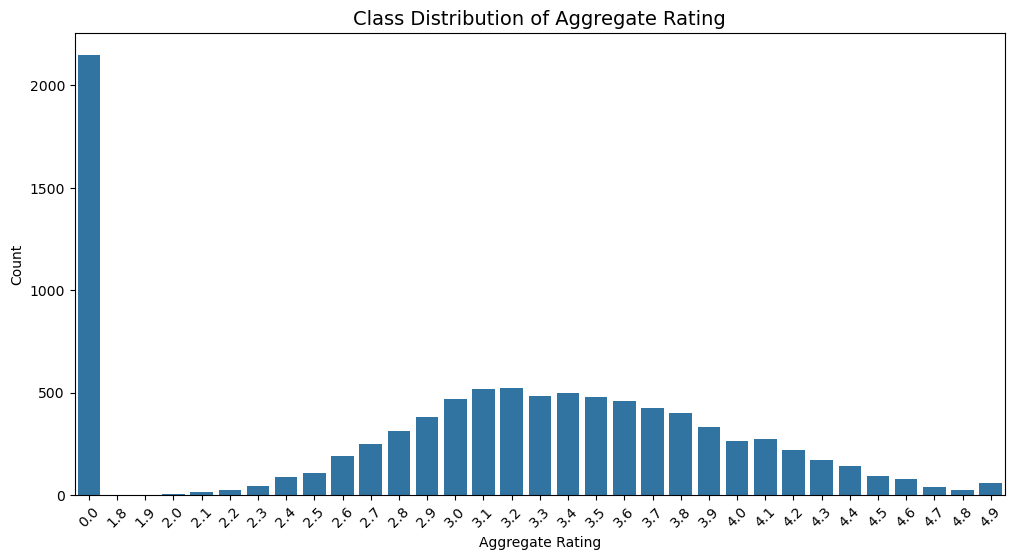

In [16]:
plt.figure(figsize=(12,6))

sns.countplot(
    x="Aggregate rating",
    data=df,
    order=sorted(df["Aggregate rating"].dropna().unique())
)

plt.title("Class Distribution of Aggregate Rating", fontsize=14)
plt.xlabel("Aggregate Rating")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

In [17]:
print("="*60)
print("📑 FINAL OBSERVATIONS")
print("="*60)

print(f"✔ Total Rows    : {df.shape[0]}")
print(f"✔ Total Columns : {df.shape[1]}")

print(f"\n✔ Missing Values Remaining : {df.isnull().sum().sum()}")

most_common = rating_counts.idxmax()
least_common = rating_counts.idxmin()

print(f"\n✔ Most Common Rating  : {most_common}")
print(f"✔ Least Common Rating : {least_common}")

if rating_counts.max() > 2 * rating_counts.min():
    print("\n⚠ Observation: Aggregate Rating shows class imbalance.")
else:
    print("\n✅ Observation: Aggregate Rating is relatively balanced.")

📑 FINAL OBSERVATIONS
✔ Total Rows    : 9551
✔ Total Columns : 21

✔ Missing Values Remaining : 0

✔ Most Common Rating  : 0.0
✔ Least Common Rating : 1.8

⚠ Observation: Aggregate Rating shows class imbalance.
